# TTC Delay Prediction Toronto

## Project: AI-based Delay Prediction for Toronto Transit (Bus, Subway, Streetcar)

This notebook performs end-to-end **EDA + data processing** using the unified dataset:
`dataset/ttc_delays_2017_2025_unified_with_coords_corrected.csv`.

It also incorporates exploratory ideas from `iteration_1.py` and `Data_Exploration_Graph.py` where applicable to this workflow.

### Objectives:
1. **Load and validate** the unified 2017-2025 dataset
2. **Data quality analysis** (missing values, outliers, data types)
3. **Data processing**:
   - Handle missing values
   - Normalization/transformation
   - Feature engineering
   - Address data imbalance
   - Define target variable
4. **Exploratory analysis** of processed data
5. **Save a processed dataset** for downstream modeling notebooks

In [101]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from datetime import datetime
import json

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")

Libraries imported successfully!
Pandas version: 3.0.1
NumPy version: 2.4.3
Matplotlib version: 3.10.8
Seaborn version: 0.13.2


## 1. Unified Data Import (2017-2025)

We load the already unified TTC delay dataset (with coordinates), then validate schema and temporal coverage before processing.

In [102]:
# Define paths
BASE_DIR = Path.cwd().parent
DATASET_DIR = BASE_DIR / "dataset"
UNIFIED_FILE = DATASET_DIR / "ttc_delays_2017_2025_unified_with_coords_corrected.csv"

print(f"Base directory: {BASE_DIR}")
print(f"Dataset directory: {DATASET_DIR}")
print(f"\nUnified file: {UNIFIED_FILE}")
print(f"Exists: {UNIFIED_FILE.exists()}")

Base directory: /Users/feliperosa/Downloads/02_codigos/github/centennialCollege_AICapstoneProject
Dataset directory: /Users/feliperosa/Downloads/02_codigos/github/centennialCollege_AICapstoneProject/dataset

Unified file: /Users/feliperosa/Downloads/02_codigos/github/centennialCollege_AICapstoneProject/dataset/ttc_delays_2017_2025_unified_with_coords_corrected.csv
Exists: True


In [103]:
# Load the unified dataset for all TTC modes used in the analysis
print("=" * 70)
print("LOADING UNIFIED DATASET")
print("=" * 70)

if UNIFIED_FILE.exists():
    df = pd.read_csv(UNIFIED_FILE)
    print(f"\n✓ Unified dataset loaded: {UNIFIED_FILE.name}")
    print(f"  Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"  Columns: {list(df.columns)}")
    print("\nVehicle type distribution:")
    print(df['Vehicle_Type'].value_counts(dropna=False))
    print("\nSample rows:")
    display(df.head(5))
else:
    raise FileNotFoundError(f"Unified file not found: {UNIFIED_FILE}")

LOADING UNIFIED DATASET

✓ Unified dataset loaded: ttc_delays_2017_2025_unified_with_coords_corrected.csv
  Shape: 439,717 rows × 14 columns
  Columns: ['Vehicle_Type', 'Date', 'Line', 'Time', 'Day', 'Station', 'Code', 'Min Delay', 'Min Gap', 'Bound', 'Vehicle', 'Latitude', 'Longitude', 'Description']

Vehicle type distribution:
Vehicle_Type
BUS          263762
SUBWAY       108912
STREETCAR     67043
Name: count, dtype: int64

Sample rows:


,Vehicle_Type,Date,Line,Time,Day,Station,Code,Min Delay,Min Gap,Bound,Vehicle,Latitude,Longitude,Description
0,BUS,10/2/2023,29,21:50,Monday,1 A THORBURN AVE,Utilized Off Route,10.0,20.0,S,1042.0,43.635400,-79.426945,UTILIZED OFF ROUTE
1,BUS,11/15/2025,51 LESLIE,10:08,Saturday,1 ADRA VILLAWAY,MFUS,15.0,31.0,S,3125.0,NaN,NaN,UNABLE TO MAINTAIN SCHEDULE
2,BUS,10/21/2023,34,21:30,Saturday,1 AND 3 CONCORDE PL,Mechanical,20.0,40.0,N,8853.0,43.728716,-79.328365,MECHANICAL
3,BUS,9/20/2023,96,5:10,Wednesday,1 ARROW RD,Mechanical,10.0,10.0,E,3599.0,43.736508,-79.528362,MECHANICAL
4,BUS,7/30/2025,945 KIPLING EXPRESS,14:51,Wednesday,1 BIJOU WALK,MFSH,14.0,28.0,NaN,7288.0,43.686789,-79.491158,USED AS SHUTTLE BUS


## 2. Unified Schema and Data Validation

Validate column consistency, key fields, datetime parsing, and coverage for the unified 2017-2025 dataset.

In [104]:
print("=" * 70)
print("UNIFIED DATASET VALIDATION")
print("=" * 70)

print("\nColumns and dtypes:")
for col, dt in df.dtypes.items():
    print(f"  {col:24s} -> {dt}")

required_columns = [
    'Vehicle_Type', 'Date', 'Line', 'Time', 'Day', 'Station',
    'Code', 'Description', 'Min Delay', 'Min Gap', 'Bound',
    'Vehicle', 'Latitude', 'Longitude'
]

missing_required = [c for c in required_columns if c not in df.columns]
print("\nRequired columns check:")
if missing_required:
    print(f"  ⚠ Missing required columns: {missing_required}")
else:
    print("  ✓ All required columns are present")

print("\nVehicle type distribution:")
print(df['Vehicle_Type'].value_counts(dropna=False))

UNIFIED DATASET VALIDATION

Columns and dtypes:
  Vehicle_Type             -> str
  Date                     -> str
  Line                     -> str
  Time                     -> str
  Day                      -> str
  Station                  -> str
  Code                     -> str
  Min Delay                -> float64
  Min Gap                  -> float64
  Bound                    -> str
  Vehicle                  -> float64
  Latitude                 -> float64
  Longitude                -> float64
  Description              -> str

Required columns check:
  ✓ All required columns are present

Vehicle type distribution:
Vehicle_Type
BUS          263762
SUBWAY       108912
STREETCAR     67043
Name: count, dtype: int64


In [105]:
# Datetime sanity check and coverage validation
print("=" * 70)
print("DATETIME SANITY CHECK")
print("=" * 70)

date_parsed = pd.to_datetime(df['Date'], errors='coerce')
time_parsed = pd.to_datetime(df['Time'], errors='coerce')

df['Date'] = date_parsed

print(f"\nDate parse rate: {date_parsed.notna().mean():.4f}")
print(f"Time parse rate: {time_parsed.notna().mean():.4f}")

if date_parsed.notna().any():
    print("\nDate coverage:")
    print(f"  Min date: {date_parsed.min()}")
    print(f"  Max date: {date_parsed.max()}")

    df = df[(df['Date'].dt.year >= 2017) & (df['Date'].dt.year <= 2025)]
    print(f"\n✓ Filtered to 2017-2025: {len(df):,} records")

DATETIME SANITY CHECK

Date parse rate: 1.0000
Time parse rate: 1.0000

Date coverage:
  Min date: 2017-01-01 00:00:00
  Max date: 2025-12-31 00:00:00

✓ Filtered to 2017-2025: 439,717 records


## 3. Baseline Exploration

In [106]:
# Lightweight baseline views
print("=" * 70)
print("BASELINE EXPLORATORY EXTENSIONS")
print("=" * 70)

print("\nTop 20 stations overall:")
print(df['Station'].value_counts(dropna=False).head(20))

print("\nTop 20 descriptions (incident causes proxy) overall:")
print(df['Description'].value_counts(dropna=False).head(20))

print("\nTop 10 stations by vehicle type:")
for vt in sorted(df['Vehicle_Type'].dropna().unique()):
    print(f"\n{vt}:")
    print(df[df['Vehicle_Type'] == vt]['Station'].value_counts(dropna=False).head(10))

BASELINE EXPLORATORY EXTENSIONS

Top 20 stations overall:
Station
KIPLING STATION           8217
FINCH STATION             8077
EGLINTON STATION          7074
KENNEDY STATION           6586
WILSON STATION            5665
WARDEN STATION            4741
BROADVIEW STATION         4166
KENNEDY BD STATION        3944
PIONEER VILLAGE STATIO    3939
VICTORIA PARK STATION     3889
BLOOR STATION             3883
DUNDAS WEST STATION       3761
YORK MILLS STATION        3442
KEELE STATION             3387
SHEPPARD WEST STATION     3303
EGLINTON WEST STATION     3251
MAIN STREET STATION       3148
DON MILLS STATION         3125
ISLINGTON STATION         2811
PAPE STATION              2750
Name: count, dtype: int64

Top 20 descriptions (incident causes proxy) overall:
Description
MECHANICAL                                               72573
OPERATIONS - OPERATOR                                    41347
GENERAL DELAY                                            18959
SECURITY                         

In [107]:
# Iteration baseline idea: audit recoverable missing Min Delay by Line + Station
print("\n" + "=" * 70)
print("MISSING DELAY RECOVERABILITY AUDIT")
print("=" * 70)

missing_delay = df[df['Min Delay'].isna()].copy()
missing_delay = missing_delay.dropna(subset=['Line', 'Station'])

grouped = df.groupby(['Line', 'Station'])['Min Delay']
recoverable = []
for _, row in missing_delay.iterrows():
    key = (row['Line'], row['Station'])
    if key in grouped.groups:
        recoverable.append(grouped.get_group(key).notna().any())
    else:
        recoverable.append(False)

total_missing = df['Min Delay'].isna().sum()
total_recoverable = int(pd.Series(recoverable).sum()) if len(recoverable) > 0 else 0

print(f"Total rows with missing Min Delay: {total_missing:,}")
if total_missing > 0:
    pct = 100 * total_recoverable / total_missing
    print(f"Rows potentially recoverable via Line+Station median: {total_recoverable:,} ({pct:.2f}%)")
else:
    print("Rows potentially recoverable via Line+Station median: 0 (0.00%)")


MISSING DELAY RECOVERABILITY AUDIT
Total rows with missing Min Delay: 5,129
Rows potentially recoverable via Line+Station median: 2,127 (41.47%)


## 4. Data Processing: Handle Missing Values

Analyze and handle missing values in the unified dataset.

MISSING VALUES ANALYSIS (BEFORE PROCESSING)

Columns with missing values (8):
   Column  Missing_Count  Missing_Percentage Data_Type
 Latitude         126971           28.875618   float64
Longitude         126971           28.875618   float64
    Bound          88680           20.167517       str
  Min Gap           5157            1.172800   float64
Min Delay           5129            1.166432   float64
  Vehicle           3204            0.728650   float64
     Line           3096            0.704089       str
  Station            152            0.034568       str


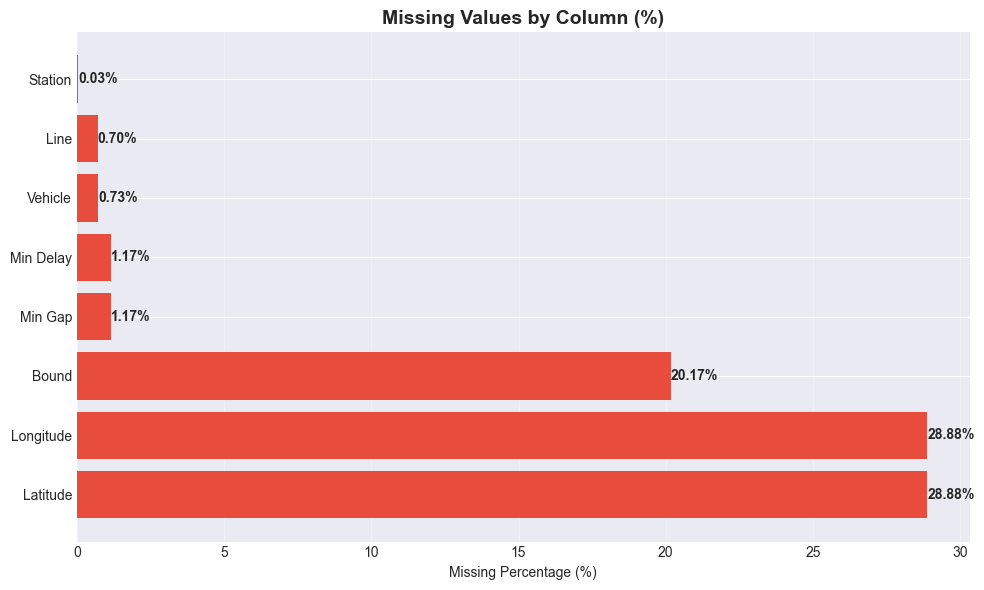


Total missing values: 359,360
Percentage of missing data: 5.84%


In [108]:
# Analyze missing values before processing
print("=" * 70)
print("MISSING VALUES ANALYSIS (BEFORE PROCESSING)")
print("=" * 70)

missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum().values,
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).values,
    'Data_Type': df.dtypes.values
})

missing_data = missing_data[missing_data['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)

if len(missing_data) > 0:
    print(f"\nColumns with missing values ({len(missing_data)}):")
    print(missing_data.to_string(index=False))
    
    # Visualize missing values
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(missing_data['Column'], missing_data['Missing_Percentage'], color='#e74c3c')
    ax.set_title('Missing Values by Column (%)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Missing Percentage (%)')
    ax.grid(axis='x', alpha=0.3)
    for i, v in enumerate(missing_data['Missing_Percentage']):
        ax.text(v, i, f'{v:.2f}%', va='center', fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("\n✅ No missing values found!")

print(f"\nTotal missing values: {df.isnull().sum().sum():,}")
print(f"Percentage of missing data: {(df.isnull().sum().sum() / (len(df) * len(df.columns)) * 100):.2f}%")

In [109]:
# Handle missing values
print("\n" + "=" * 70)
print("HANDLING MISSING VALUES")
print("=" * 70)

df_processed = df.copy()
initial_missing = df_processed.isnull().sum().sum()

# Strategy for each column
print("\nMissing value handling strategy:")

# 1. Bound: Fill with 'Unknown' (categorical)
if 'Bound' in df_processed.columns:
    missing_bound = df_processed['Bound'].isnull().sum()
    if missing_bound > 0:
        df_processed['Bound'] = df_processed['Bound'].fillna('Unknown')
        print(f"  ✓ Bound: Filled {missing_bound:,} missing values with 'Unknown'")

# 2. Vehicle: Fill with 0 or mode (numerical)
if 'Vehicle' in df_processed.columns:
    missing_vehicle = df_processed['Vehicle'].isnull().sum()
    if missing_vehicle > 0:
        # Use mode by vehicle type
        for vtype in df_processed['Vehicle_Type'].unique():
            mode_vehicle = df_processed[df_processed['Vehicle_Type'] == vtype]['Vehicle'].mode()
            if len(mode_vehicle) > 0:
                df_processed.loc[(df_processed['Vehicle_Type'] == vtype) & 
                                (df_processed['Vehicle'].isnull()), 'Vehicle'] = mode_vehicle[0]
            else:
                df_processed.loc[(df_processed['Vehicle_Type'] == vtype) & 
                                (df_processed['Vehicle'].isnull()), 'Vehicle'] = 0
        print(f"  ✓ Vehicle: Filled {missing_vehicle:,} missing values with mode/0")

# 3. Line: Fill with 'Unknown' (categorical)
if 'Line' in df_processed.columns:
    missing_line = df_processed['Line'].isnull().sum()
    if missing_line > 0:
        df_processed['Line'] = df_processed['Line'].fillna('Unknown')
        print(f"  ✓ Line: Filled {missing_line:,} missing values with 'Unknown'")

# 4. Station: Fill with 'Unknown' (categorical)
if 'Station' in df_processed.columns:
    missing_station = df_processed['Station'].isnull().sum()
    if missing_station > 0:
        df_processed['Station'] = df_processed['Station'].fillna('Unknown')
        print(f"  ✓ Station: Filled {missing_station:,} missing values with 'Unknown'")

# 5. Min Delay and Min Gap: Fill with median by vehicle type
for col in ['Min Delay', 'Min Gap']:
    if col in df_processed.columns:
        missing = df_processed[col].isnull().sum()
        if missing > 0:
            for vtype in df_processed['Vehicle_Type'].unique():
                median_val = df_processed[df_processed['Vehicle_Type'] == vtype][col].median()
                df_processed.loc[(df_processed['Vehicle_Type'] == vtype) & 
                                (df_processed[col].isnull()), col] = median_val
            print(f"  ✓ {col}: Filled {missing:,} missing values with median by vehicle type")

# 6. Date and Time: Drop rows with missing critical temporal data
if 'Date' in df_processed.columns:
    missing_date = df_processed['Date'].isnull().sum()
    if missing_date > 0:
        df_processed = df_processed.dropna(subset=['Date'])
        print(f"  ✓ Date: Dropped {missing_date:,} rows with missing dates")

final_missing = df_processed.isnull().sum().sum()
print(f"\n✓ Missing values handled!")
print(f"  Before: {initial_missing:,} missing values")
print(f"  After: {final_missing:,} missing values")
print(f"  Remaining missing: {df_processed.isnull().sum().sum():,}")

# Update df for further processing
df = df_processed.copy()


HANDLING MISSING VALUES

Missing value handling strategy:
  ✓ Bound: Filled 88,680 missing values with 'Unknown'
  ✓ Vehicle: Filled 3,204 missing values with mode/0
  ✓ Line: Filled 3,096 missing values with 'Unknown'
  ✓ Station: Filled 152 missing values with 'Unknown'
  ✓ Min Delay: Filled 5,129 missing values with median by vehicle type
  ✓ Min Gap: Filled 5,157 missing values with median by vehicle type

✓ Missing values handled!
  Before: 359,360 missing values
  After: 253,942 missing values
  Remaining missing: 253,942


In [110]:
# Checa missing por tipo de veículo
lat_missing = df['Latitude'].isna()
lon_missing = df['Longitude'].isna()

summary = (
    df.groupby('Vehicle_Type', dropna=False)
      .agg(
          n_rows=('Vehicle_Type', 'size'),
          missing_lat=('Latitude', lambda s: s.isna().sum()),
          missing_lon=('Longitude', lambda s: s.isna().sum()),
          missing_both=('Latitude', lambda s: (df.loc[s.index, 'Latitude'].isna() & df.loc[s.index, 'Longitude'].isna()).sum()),
      )
)

summary['missing_lat_%'] = (summary['missing_lat'] / summary['n_rows'] * 100).round(2)
summary['missing_lon_%'] = (summary['missing_lon'] / summary['n_rows'] * 100).round(2)
summary['missing_both_%'] = (summary['missing_both'] / summary['n_rows'] * 100).round(2)

# Ordena por falta de Latitude (pode trocar se preferir)
summary = summary.sort_values('missing_lat', ascending=False)

display(summary)

,n_rows,missing_lat,missing_lon,missing_both,missing_lat_%,missing_lon_%,missing_both_%
Vehicle_Type,,,,,,,
BUS,263762,104669,104669,104669,39.68,39.68,39.68
STREETCAR,67043,19858,19858,19858,29.62,29.62,29.62
SUBWAY,108912,2444,2444,2444,2.24,2.24,2.24


## 5. Feature Engineering

Create new features from existing data to improve model performance.

In [111]:
# Extract temporal features
print("=" * 70)
print("FEATURE ENGINEERING")
print("=" * 70)

# Extract temporal features from Date
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek  # 0=Monday, 6=Sunday
df['DayName'] = df['Date'].dt.day_name()
df['DayOfMonth'] = df['Date'].dt.day
df['WeekOfYear'] = df['Date'].dt.isocalendar().week

# Extract hour from Time
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M:%S', errors='coerce').dt.hour
df['Minute'] = pd.to_datetime(df['Time'], format='%H:%M:%S', errors='coerce').dt.minute

# Cyclical encoding for temporal features (better for ML models)
df['Hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
df['Hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)
df['DayOfWeek_sin'] = np.sin(2 * np.pi * df['DayOfWeek'] / 7)
df['DayOfWeek_cos'] = np.cos(2 * np.pi * df['DayOfWeek'] / 7)
df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

# Time-based features
df['IsWeekend'] = (df['DayOfWeek'] >= 5).astype(int)
df['IsRushHour'] = df['Hour'].apply(lambda x: 1 if (7 <= x <= 9) or (17 <= x <= 19) else 0)
df['IsPeakHour'] = df['Hour'].apply(lambda x: 1 if (6 <= x <= 10) or (15 <= x <= 20) else 0)
df['IsNight'] = df['Hour'].apply(lambda x: 1 if (22 <= x <= 23) or (0 <= x <= 5) else 0)

# Season feature
df['Season'] = df['Month'].apply(lambda x: 
    'Spring' if 3 <= x <= 5 else
    'Summer' if 6 <= x <= 8 else
    'Fall' if 9 <= x <= 11 else 'Winter')

# Delay ratio feature
df['Delay_Ratio'] = df['Min Delay'] / (df['Min Gap'] + 1)  # +1 to avoid division by zero

# Categorical encoding for Vehicle_Type (one-hot will be done later if needed)
df['Vehicle_Type_Encoded'] = df['Vehicle_Type'].astype('category').cat.codes

print("✓ Temporal features created:")
print("  - Year, Month, DayOfWeek, DayName, DayOfMonth, WeekOfYear")
print("  - Hour, Minute")
print("  - Cyclical encoding: Hour_sin/cos, DayOfWeek_sin/cos, Month_sin/cos")
print("  - Time flags: IsWeekend, IsRushHour, IsPeakHour, IsNight")
print("  - Season")
print("  - Delay_Ratio")
print("  - Vehicle_Type_Encoded")

print(f"\nNew shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nNew columns: {[col for col in df.columns if col not in ['Date', 'Time', 'Day', 'Vehicle_Type']]}")

FEATURE ENGINEERING
✓ Temporal features created:
  - Year, Month, DayOfWeek, DayName, DayOfMonth, WeekOfYear
  - Hour, Minute
  - Cyclical encoding: Hour_sin/cos, DayOfWeek_sin/cos, Month_sin/cos
  - Time flags: IsWeekend, IsRushHour, IsPeakHour, IsNight
  - Season
  - Delay_Ratio
  - Vehicle_Type_Encoded

New shape: 439,717 rows × 35 columns

New columns: ['Line', 'Station', 'Code', 'Min Delay', 'Min Gap', 'Bound', 'Vehicle', 'Latitude', 'Longitude', 'Description', 'Year', 'Month', 'DayOfWeek', 'DayName', 'DayOfMonth', 'WeekOfYear', 'Hour', 'Minute', 'Hour_sin', 'Hour_cos', 'DayOfWeek_sin', 'DayOfWeek_cos', 'Month_sin', 'Month_cos', 'IsWeekend', 'IsRushHour', 'IsPeakHour', 'IsNight', 'Season', 'Delay_Ratio', 'Vehicle_Type_Encoded']


In [112]:
# Target Variable Definition
#
# We define the target variable for delay prediction.
#
# - Primary target (regression): Min Delay (minutes)
# - Optional (classification): bucketed delay categories (0–5, 5–15, 15–30, 30+)


TARGET VARIABLE DEFINITION

Primary Target Variable: Min Delay
  Type: Continuous (Regression)
  Description: Minutes of delay

Target Variable Statistics:
count    439717.000000
mean         15.085444
std          42.164710
min         -30.000000
25%           3.000000
50%          10.000000
75%          15.000000
max        1158.000000
Name: Min Delay, dtype: float64

Delay Categories (for potential classification):
Delay_Category
Medium (5-15min)      194200
High (15-30min)        79912
Low (0-5min)           43515
Very High (30+min)     22504
Name: count, dtype: int64

Percentage distribution:
Delay_Category
Medium (5-15min)      57.095648
High (15-30min)       23.494477
Low (0-5min)          12.793600
Very High (30+min)     6.616274
Name: proportion, dtype: float64


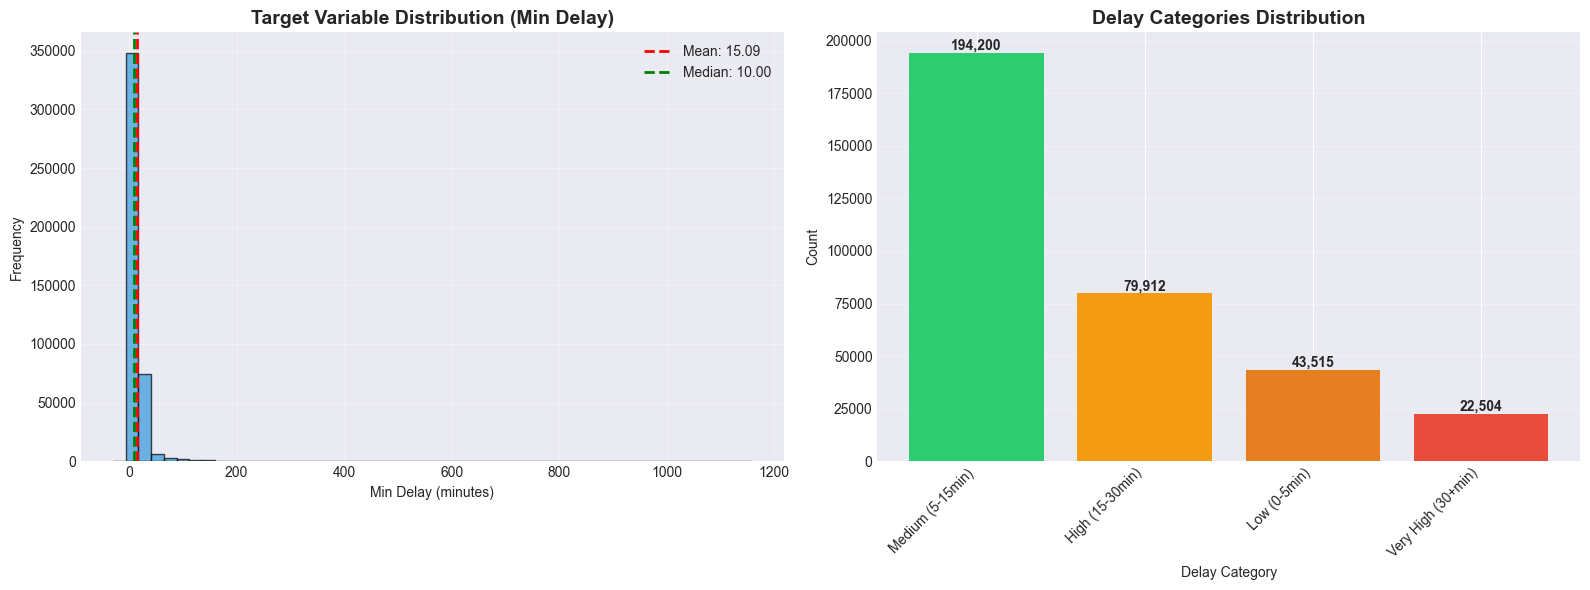


✓ Target variable defined: Min Delay
  Total records: 439,717
  Records with valid target: 439,717


In [113]:
# Define target variable
print("=" * 70)
print("TARGET VARIABLE DEFINITION")
print("=" * 70)

# Primary target: Min Delay (continuous - regression problem)
target_variable = 'Min Delay'

print(f"\nPrimary Target Variable: {target_variable}")
print(f"  Type: Continuous (Regression)")
print(f"  Description: Minutes of delay")

# Analyze target variable
print(f"\nTarget Variable Statistics:")
print(df[target_variable].describe())

# Optional: Create delay categories for classification (if needed)
df['Delay_Category'] = pd.cut(
    df[target_variable],
    bins=[0, 5, 15, 30, float('inf')],
    labels=['Low (0-5min)', 'Medium (5-15min)', 'High (15-30min)', 'Very High (30+min)']
)

print(f"\nDelay Categories (for potential classification):")
print(df['Delay_Category'].value_counts())
print(f"\nPercentage distribution:")
print(df['Delay_Category'].value_counts(normalize=True) * 100)

# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribution of Min Delay
axes[0].hist(df[target_variable].dropna(), bins=50, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].set_title('Target Variable Distribution (Min Delay)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Min Delay (minutes)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df[target_variable].mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {df[target_variable].mean():.2f}')
axes[0].axvline(df[target_variable].median(), color='green', linestyle='--', linewidth=2, 
                label=f'Median: {df[target_variable].median():.2f}')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Delay categories
delay_cat_counts = df['Delay_Category'].value_counts()
axes[1].bar(range(len(delay_cat_counts)), delay_cat_counts.values, 
           color=['#2ecc71', '#f39c12', '#e67e22', '#e74c3c'])
axes[1].set_title('Delay Categories Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Delay Category')
axes[1].set_ylabel('Count')
axes[1].set_xticks(range(len(delay_cat_counts)))
axes[1].set_xticklabels([str(cat) for cat in delay_cat_counts.index], rotation=45, ha='right')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(delay_cat_counts.values):
    axes[1].text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n✓ Target variable defined: {target_variable}")
print(f"  Total records: {len(df):,}")
print(f"  Records with valid target: {df[target_variable].notna().sum():,}")

## 6. Normalization and Transformation

Apply normalization and transformations to numerical features (e.g., log-transform for skewed targets, robust scaling for outlier-heavy variables).

In [114]:
# Assess normalization needs
print("=" * 70)
print("NORMALIZATION ASSESSMENT")
print("=" * 70)

numerical_features = ['Min Delay', 'Min Gap', 'Vehicle', 'Hour', 'Delay_Ratio']
normalization_assessment = []

for col in numerical_features:
    if col in df.columns:
        data = df[col].dropna()
        mean_val = data.mean()
        std_val = data.std()
        min_val = data.min()
        max_val = data.max()
        range_val = max_val - min_val
        cv = std_val / mean_val if mean_val != 0 else np.inf
        
        normalization_assessment.append({
            'Feature': col,
            'Mean': mean_val,
            'Std': std_val,
            'Min': min_val,
            'Max': max_val,
            'Range': range_val,
            'CV': cv,
            'Needs_Normalization': abs(cv) > 1 or range_val > 100
        })

norm_df = pd.DataFrame(normalization_assessment)
print("\nNormalization Assessment:")
print(norm_df.to_string(index=False))

NORMALIZATION ASSESSMENT

Normalization Assessment:
    Feature        Mean         Std   Min     Max   Range       CV  Needs_Normalization
  Min Delay   15.085444   42.164710 -30.0  1158.0  1188.0 2.795059                 True
    Min Gap   23.892572   44.790072   0.0  1158.0  1158.0 1.874644                 True
    Vehicle 4947.806705 3564.310998   0.0 98035.0 98035.0 0.720382                 True
       Hour   11.588297    5.547492   0.0    23.0    23.0 0.478715                False
Delay_Ratio    0.538389    3.110099  -5.0   585.0   590.0 5.776677                 True



APPLYING NORMALIZATION AND TRANSFORMATIONS
✓ Min Delay: Applied log transformation (Min_Delay_Log)
✓ Min Gap: Applied RobustScaler (Min_Gap_Scaled)
✓ Vehicle: Applied StandardScaler (Vehicle_Scaled)
✓ Delay_Ratio: Applied RobustScaler (Delay_Ratio_Scaled)


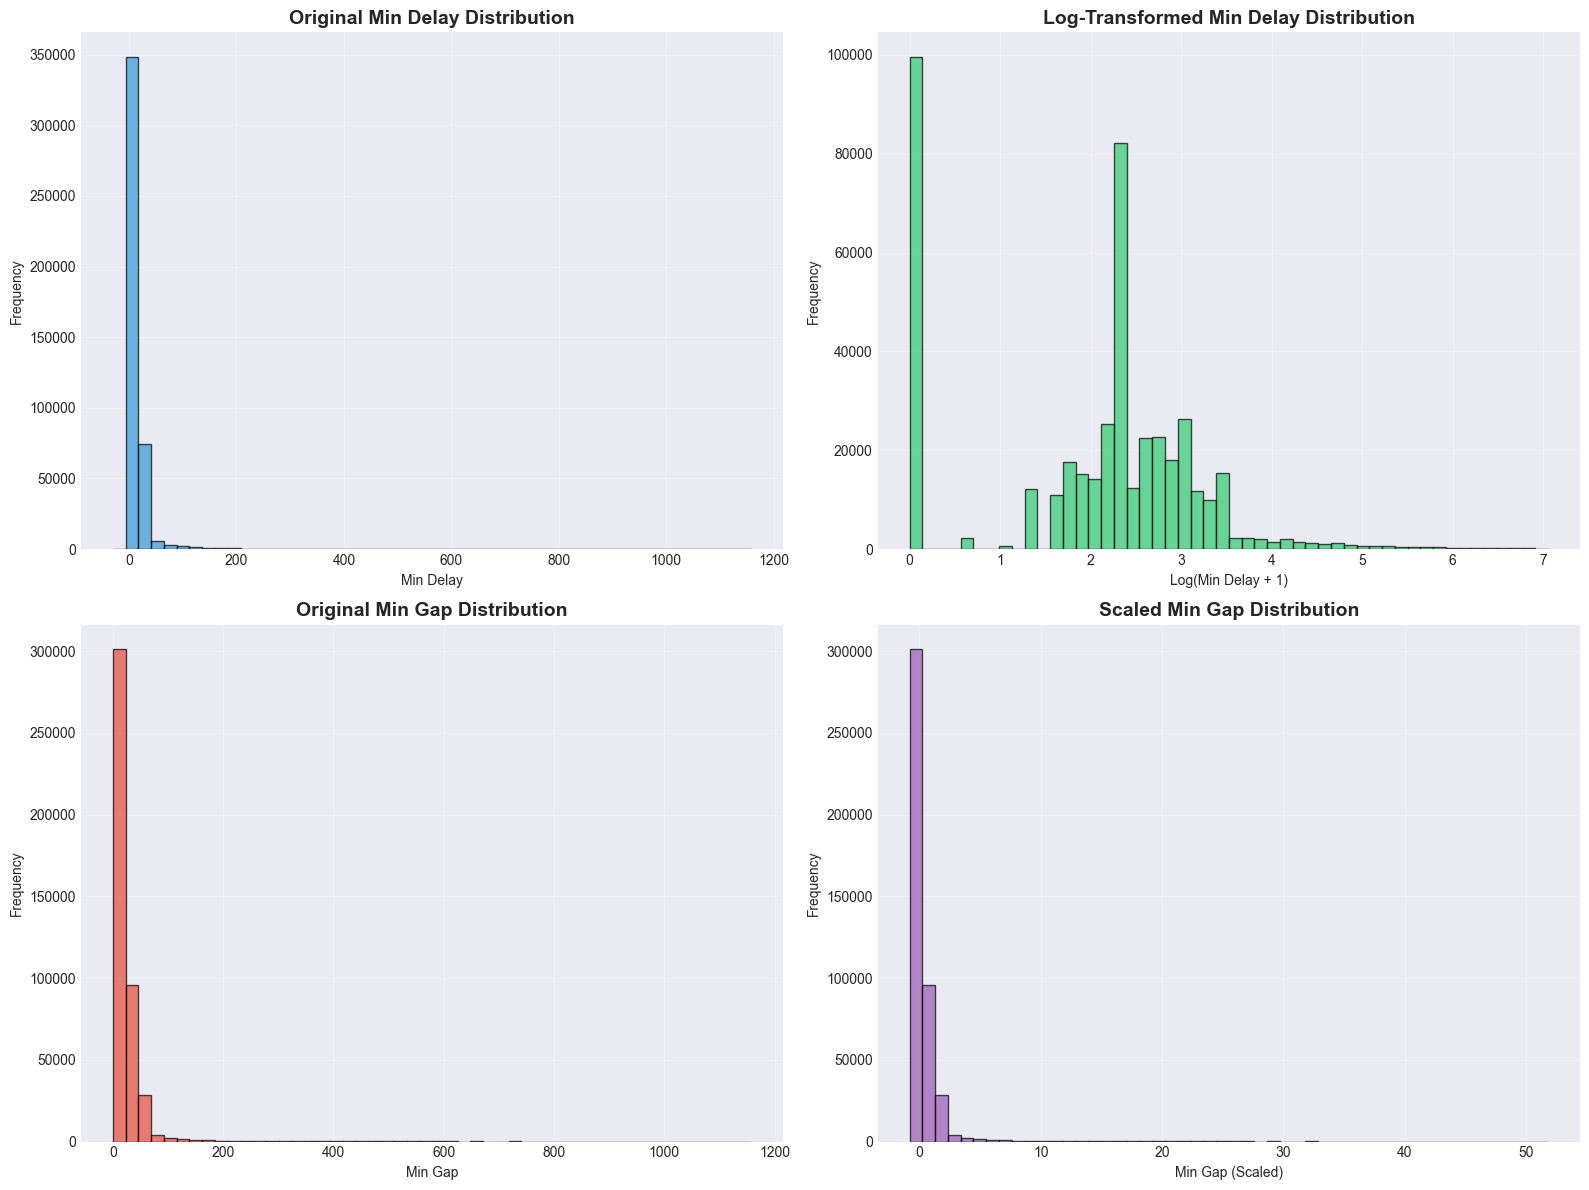


✓ Normalization and transformations applied!
  Note: Original columns preserved for reference


In [115]:
# Apply normalization/transformation
print("\n" + "=" * 70)
print("APPLYING NORMALIZATION AND TRANSFORMATIONS")
print("=" * 70)

from sklearn.preprocessing import StandardScaler, RobustScaler

# Store original values for reference
df['Min_Delay_Original'] = df['Min Delay'].copy()
df['Min_Gap_Original'] = df['Min Gap'].copy()

# 1. Log transformation for Min Delay (right-skewed)
df['Min_Delay_Log'] = np.log1p(df['Min Delay'])  # log(1+x) to handle zeros
print("✓ Min Delay: Applied log transformation (Min_Delay_Log)")

# 2. Standardization for Min Gap (using RobustScaler - less sensitive to outliers)
scaler_min_gap = RobustScaler()
df['Min_Gap_Scaled'] = scaler_min_gap.fit_transform(df[['Min Gap']])
print("✓ Min Gap: Applied RobustScaler (Min_Gap_Scaled)")

# 3. Standardization for Vehicle (if needed)
if 'Vehicle' in df.columns:
    scaler_vehicle = StandardScaler()
    df['Vehicle_Scaled'] = scaler_vehicle.fit_transform(df[['Vehicle']])
    print("✓ Vehicle: Applied StandardScaler (Vehicle_Scaled)")

# 4. Standardization for Delay_Ratio
if 'Delay_Ratio' in df.columns:
    scaler_ratio = RobustScaler()
    df['Delay_Ratio_Scaled'] = scaler_ratio.fit_transform(df[['Delay_Ratio']])
    print("✓ Delay_Ratio: Applied RobustScaler (Delay_Ratio_Scaled)")

# Visualize transformations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Original Min Delay
axes[0, 0].hist(df['Min_Delay_Original'].dropna(), bins=50, color='#3498db', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Original Min Delay Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Min Delay')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(alpha=0.3)

# Log-transformed Min Delay
axes[0, 1].hist(df['Min_Delay_Log'].dropna(), bins=50, color='#2ecc71', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Log-Transformed Min Delay Distribution', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Log(Min Delay + 1)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(alpha=0.3)

# Original Min Gap
axes[1, 0].hist(df['Min_Gap_Original'].dropna(), bins=50, color='#e74c3c', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Original Min Gap Distribution', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Min Gap')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(alpha=0.3)

# Scaled Min Gap
axes[1, 1].hist(df['Min_Gap_Scaled'].dropna(), bins=50, color='#9b59b6', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Scaled Min Gap Distribution', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Min Gap (Scaled)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Normalization and transformations applied!")
print("  Note: Original columns preserved for reference")

## 7. Data Imbalance Analysis

Analyze imbalance across **years** and **vehicle types** (this will inform later sampling / validation strategies).

In [116]:
# Analyze data imbalance
print("=" * 70)
print("DATA IMBALANCE ANALYSIS")
print("=" * 70)

# Records by year and vehicle type
imbalance_matrix = pd.crosstab(df['Year'], df['Vehicle_Type'], margins=True)
print("\nRecords by Year and Vehicle Type:")
print(imbalance_matrix)

# Calculate imbalance ratios
print("\nImbalance Ratios (relative to total):")
imbalance_pct = pd.crosstab(df['Year'], df['Vehicle_Type'], normalize='index') * 100
print(imbalance_pct.round(2))

# Yearly distribution
yearly_counts = df.groupby('Year').size()
print(f"\nYearly Distribution:")
print(yearly_counts)
print(f"\nMax/Min ratio: {yearly_counts.max() / yearly_counts.min():.2f}x")
print(f"  Most records: {yearly_counts.idxmax()} ({yearly_counts.max():,})")
print(f"  Least records: {yearly_counts.idxmin()} ({yearly_counts.min():,})")

DATA IMBALANCE ANALYSIS

Records by Year and Vehicle Type:
Vehicle_Type     BUS  STREETCAR  SUBWAY     All
Year                                           
2017            5307       1300    7590   14197
2018            6981       1632    1873   10486
2019            6774       1600    1871   10245
2020            4286        803    1339    6428
2021            2832       1018    1216    5066
2022           58707      17652   19895   96254
2023           56206      14413   22949   93568
2024           59640      14206   26466  100312
2025           63029      14419   25713  103161
All           263762      67043  108912  439717

Imbalance Ratios (relative to total):
Vehicle_Type    BUS  STREETCAR  SUBWAY
Year                                  
2017          37.38       9.16   53.46
2018          66.57      15.56   17.86
2019          66.12      15.62   18.26
2020          66.68      12.49   20.83
2021          55.90      20.09   24.00
2022          60.99      18.34   20.67
2023          

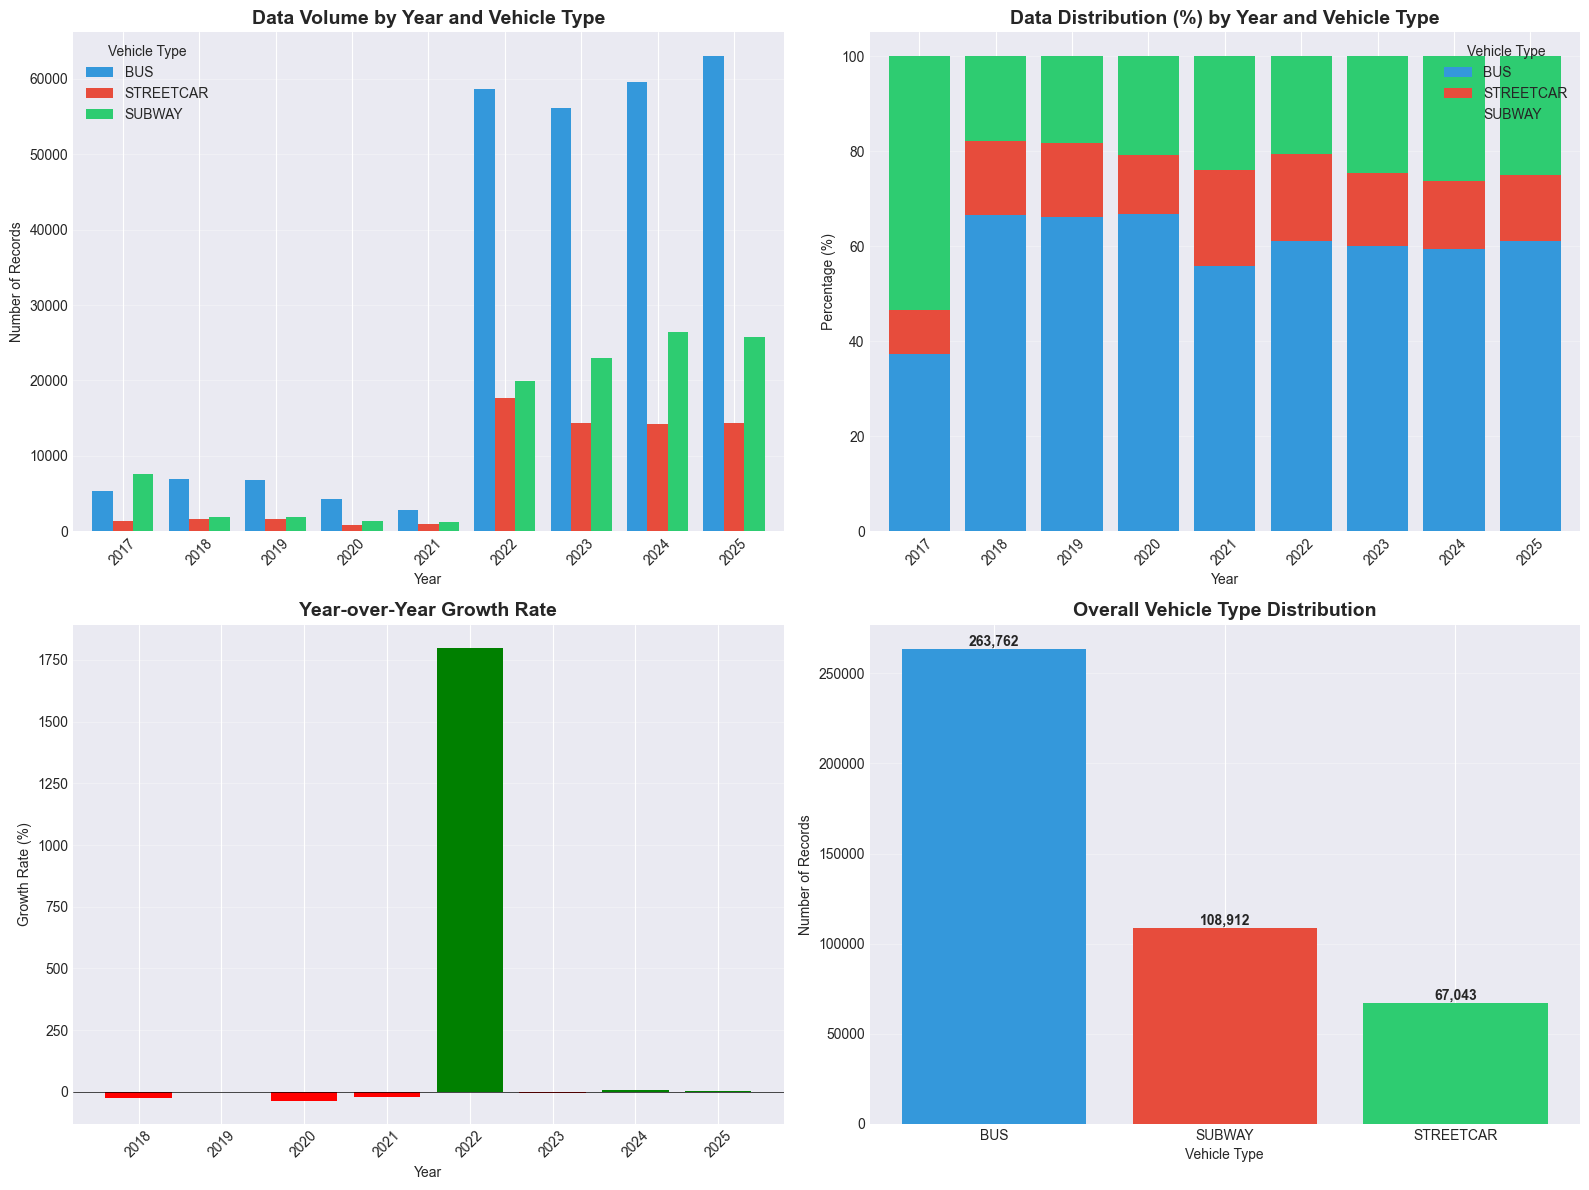


DATA IMBALANCE HANDLING STRATEGY

Recommendations:
  1. Use stratified sampling when splitting data
  2. Consider class weights in models
  3. Use time-based split (earlier years for training, later for testing)
  4. Consider resampling techniques if needed
  5. Monitor model performance across different vehicle types and years


In [117]:
# Visualize data imbalance
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Records count by year and vehicle type
imbalance_counts = pd.crosstab(df['Year'], df['Vehicle_Type'])
imbalance_counts.plot(kind='bar', ax=axes[0, 0], color=['#3498db', '#e74c3c', '#2ecc71'], width=0.8)
axes[0, 0].set_title('Data Volume by Year and Vehicle Type', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Number of Records')
axes[0, 0].legend(title='Vehicle Type')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Percentage by year and vehicle type
imbalance_counts_pct = pd.crosstab(df['Year'], df['Vehicle_Type'], normalize='index') * 100
imbalance_counts_pct.plot(kind='bar', stacked=True, ax=axes[0, 1], 
                          color=['#3498db', '#e74c3c', '#2ecc71'], width=0.8)
axes[0, 1].set_title('Data Distribution (%) by Year and Vehicle Type', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Percentage (%)')
axes[0, 1].legend(title='Vehicle Type')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Yearly growth rate
growth_rate = yearly_counts.pct_change() * 100
axes[1, 0].bar(growth_rate.index.astype(str), growth_rate.values, 
               color=['green' if x > 0 else 'red' for x in growth_rate.values])
axes[1, 0].set_title('Year-over-Year Growth Rate', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Growth Rate (%)')
axes[1, 0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Vehicle type distribution
vehicle_counts = df['Vehicle_Type'].value_counts()
axes[1, 1].bar(vehicle_counts.index, vehicle_counts.values, 
              color=['#3498db', '#e74c3c', '#2ecc71'])
axes[1, 1].set_title('Overall Vehicle Type Distribution', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Vehicle Type')
axes[1, 1].set_ylabel('Number of Records')
axes[1, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(vehicle_counts.values):
    axes[1, 1].text(i, v, f'{v:,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Handling strategy for data imbalance
print("\n" + "=" * 70)
print("DATA IMBALANCE HANDLING STRATEGY")
print("=" * 70)
print("\nRecommendations:")
print("  1. Use stratified sampling when splitting data")
print("  2. Consider class weights in models")
print("  3. Use time-based split (earlier years for training, later for testing)")
print("  4. Consider resampling techniques if needed")
print("  5. Monitor model performance across different vehicle types and years")

## 8. Processed Dataset Summary

Quick check that the dataset is consistent, has the expected columns/features, and is ready to be saved for future modeling notebooks.

In [118]:
# Final dataset summary
print("=" * 70)
print("PROCESSED DATASET SUMMARY")
print("=" * 70)

print(f"\nDataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nDate Range: {df['Date'].min().date()} to {df['Date'].max().date()}")

print(f"\nVehicle Type Distribution:")
print(df['Vehicle_Type'].value_counts())
print(f"\nPercentage:")
print((df['Vehicle_Type'].value_counts() / len(df) * 100).round(2))

print(f"\nYear Distribution:")
year_counts = df['Year'].value_counts().sort_index()
print(year_counts)

print(f"\nMissing Values (after processing):")
remaining_missing = df.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]
if len(remaining_missing) > 0:
    print(remaining_missing)
else:
    print("  ✅ No missing values remaining!")

print(f"\nTarget Variable: {target_variable}")
print(f"  Mean: {df[target_variable].mean():.2f} minutes")
print(f"  Median: {df[target_variable].median():.2f} minutes")
print(f"  Std: {df[target_variable].std():.2f} minutes")
print(f"  Min: {df[target_variable].min():.2f} minutes")
print(f"  Max: {df[target_variable].max():.2f} minutes")

print(f"\nKey Features Created:")
feature_list = [
    'Year', 'Month', 'DayOfWeek', 'Hour',
    'Hour_sin', 'Hour_cos', 'DayOfWeek_sin', 'DayOfWeek_cos', 'Month_sin', 'Month_cos',
    'IsWeekend', 'IsRushHour', 'IsPeakHour', 'IsNight',
    'Season', 'Delay_Ratio',
    'Min_Delay_Log', 'Min_Gap_Scaled', 'Delay_Ratio_Scaled',
    'Delay_Category'
]
print(f"  Temporal: {[f for f in feature_list if f in df.columns]}")
print(f"  Cyclical: {[f for f in df.columns if '_sin' in f or '_cos' in f]}")
print(f"  Binary flags: {[f for f in df.columns if f.startswith('Is')]}")
print(f"  Transformed: {[f for f in df.columns if 'Scaled' in f or 'Log' in f]}")

print(f"\n✓ Dataset ready for modeling!")
print(f"  Total features: {len(df.columns)}")
print(f"  Target variable: {target_variable}")
print(f"  Records: {len(df):,}")

PROCESSED DATASET SUMMARY

Dataset Shape: 439,717 rows × 42 columns

Date Range: 2017-01-01 to 2025-12-31

Vehicle Type Distribution:
Vehicle_Type
BUS          263762
SUBWAY       108912
STREETCAR     67043
Name: count, dtype: int64

Percentage:
Vehicle_Type
BUS          59.98
SUBWAY       24.77
STREETCAR    15.25
Name: count, dtype: float64

Year Distribution:
Year
2017     14197
2018     10486
2019     10245
2020      6428
2021      5066
2022     96254
2023     93568
2024    100312
2025    103161
Name: count, dtype: int64

Missing Values (after processing):
Latitude          126971
Longitude         126971
Hour              411041
Minute            411041
Hour_sin          411041
Hour_cos          411041
Delay_Category     99586
Min_Delay_Log          2
dtype: int64

Target Variable: Min Delay
  Mean: 15.09 minutes
  Median: 10.00 minutes
  Std: 42.16 minutes
  Min: -30.00 minutes
  Max: 1158.00 minutes

Key Features Created:
  Temporal: ['Year', 'Month', 'DayOfWeek', 'Hour', 'Hour_s

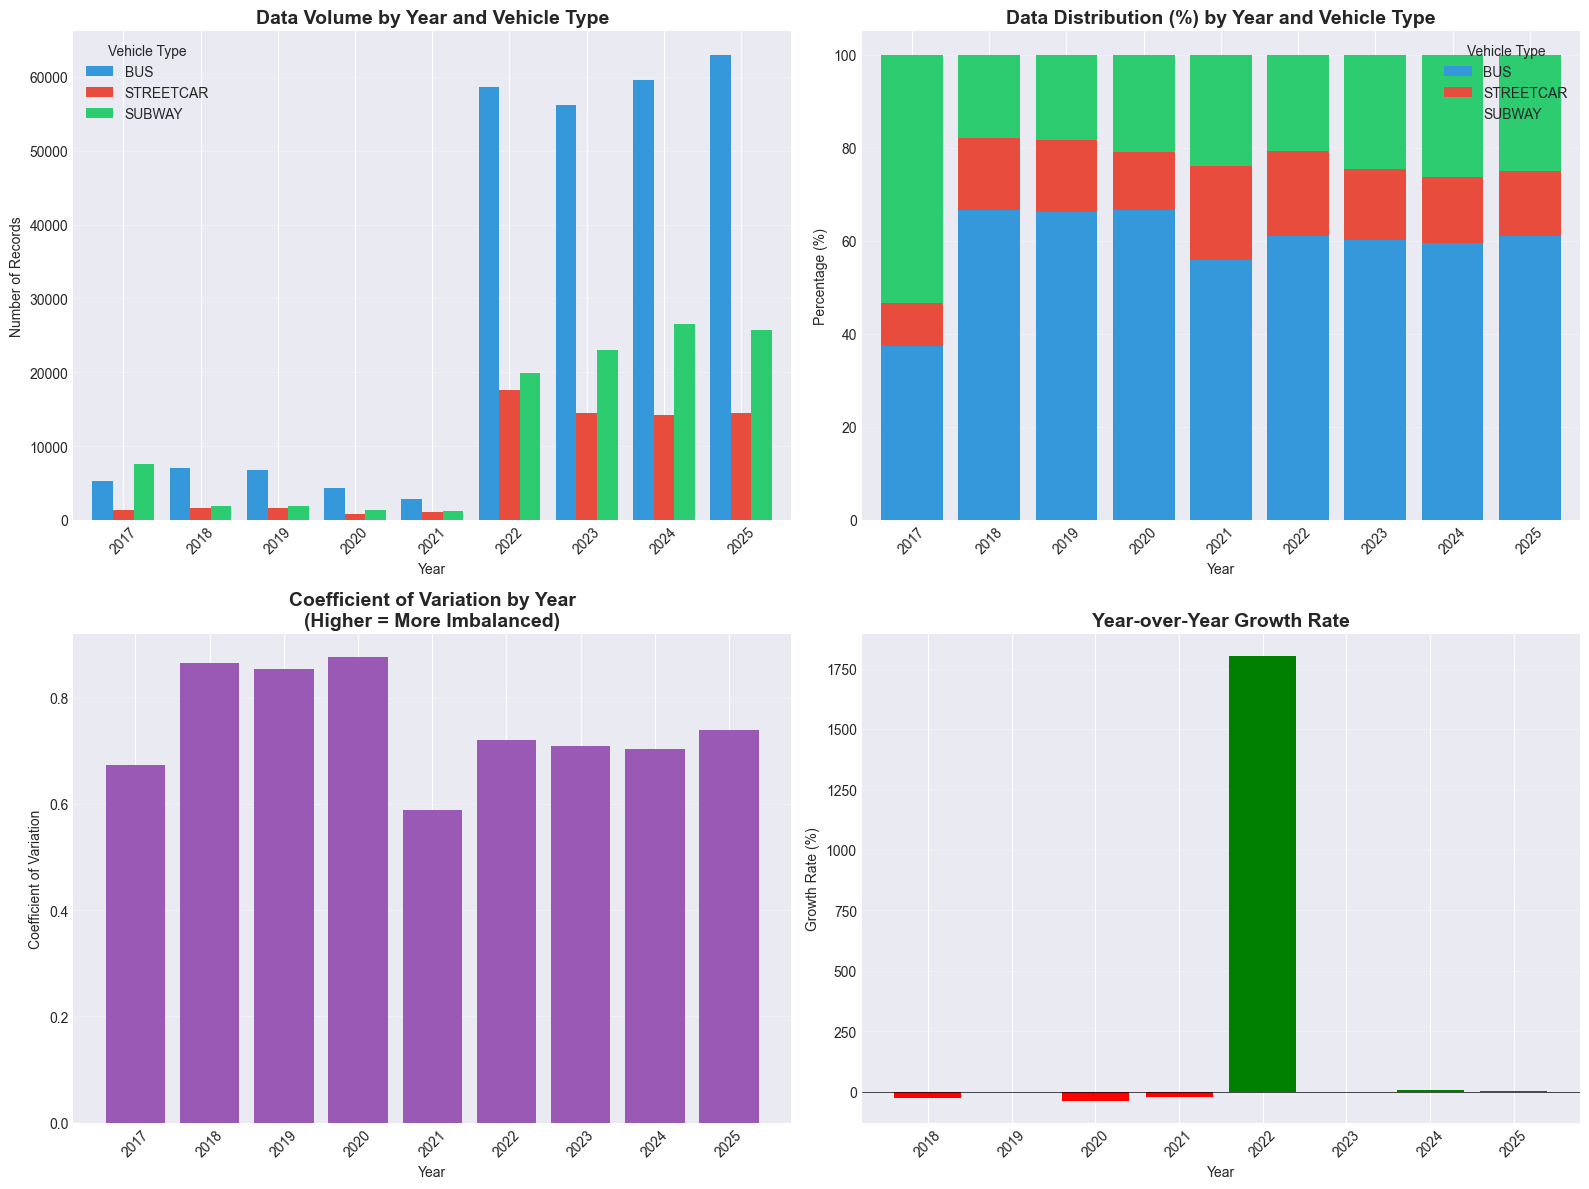


Key Observations:
  - Total records: 439,717
  - Year range: 2017 to 2025
  - Most records in year: 2025 (103,161 records)
  - Least records in year: 2021 (5,066 records)
  - Ratio (max/min): 20.36x


In [119]:
# Visualize data imbalance
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Records count by year and vehicle type
imbalance_counts = pd.crosstab(df['Year'], df['Vehicle_Type'])
imbalance_counts.plot(kind='bar', ax=axes[0, 0], color=['#3498db', '#e74c3c', '#2ecc71'], width=0.8)
axes[0, 0].set_title('Data Volume by Year and Vehicle Type', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Number of Records')
axes[0, 0].legend(title='Vehicle Type')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Percentage by year and vehicle type
imbalance_counts_pct = pd.crosstab(df['Year'], df['Vehicle_Type'], normalize='index') * 100
imbalance_counts_pct.plot(kind='bar', stacked=True, ax=axes[0, 1], 
                          color=['#3498db', '#e74c3c', '#2ecc71'], width=0.8)
axes[0, 1].set_title('Data Distribution (%) by Year and Vehicle Type', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Percentage (%)')
axes[0, 1].legend(title='Vehicle Type')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Coefficient of variation by year (measure of imbalance)
cv_by_year = df.groupby('Year')['Vehicle_Type'].apply(lambda x: x.value_counts().std() / x.value_counts().mean())
axes[1, 0].bar(cv_by_year.index.astype(str), cv_by_year.values, color='#9b59b6')
axes[1, 0].set_title('Coefficient of Variation by Year\n(Higher = More Imbalanced)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Coefficient of Variation')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Yearly growth rate
yearly_counts = df.groupby('Year').size()
growth_rate = yearly_counts.pct_change() * 100
axes[1, 1].bar(growth_rate.index.astype(str), growth_rate.values, 
               color=['green' if x > 0 else 'red' for x in growth_rate.values])
axes[1, 1].set_title('Year-over-Year Growth Rate', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Growth Rate (%)')
axes[1, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey Observations:")
print(f"  - Total records: {len(df):,}")
print(f"  - Year range: {df['Year'].min()} to {df['Year'].max()}")
print(f"  - Most records in year: {yearly_counts.idxmax()} ({yearly_counts.max():,} records)")
print(f"  - Least records in year: {yearly_counts.idxmin()} ({yearly_counts.min():,} records)")
print(f"  - Ratio (max/min): {yearly_counts.max() / yearly_counts.min():.2f}x")

## 9. Save Processed Dataset

Save a processed, unified dataset that can be used later for training (we are **not** training yet in this notebook).

In [120]:
# Save processed dataset for future modeling (no training here)
print("=" * 70)
print("SAVING PROCESSED DATASET")
print("=" * 70)

OUTPUT_DIR = BASE_DIR / "aiProject" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

processed_file = OUTPUT_DIR / "ttc_delays_2017_2025_unified_with_coords_corrected_treated.csv"

# Pick a reasonable set of columns (raw + engineered + transformed + target)
columns_to_save = [
    # identifiers / raw
    'Vehicle_Type', 'Date', 'Time', 'Day', 'Line', 'Station', 'Code', 'Bound', 'Vehicle',
    # target + core numeric
    'Min Delay', 'Min Gap',
    # engineered temporal
    'Year', 'Month', 'DayOfWeek', 'DayName', 'DayOfMonth', 'WeekOfYear', 'Hour', 'Minute',
    # cyclical encodings
    'Hour_sin', 'Hour_cos', 'DayOfWeek_sin', 'DayOfWeek_cos', 'Month_sin', 'Month_cos',
    # flags
    'IsWeekend', 'IsRushHour', 'IsPeakHour', 'IsNight',
    # engineered
    'Season', 'Delay_Ratio',
    # transformed
    'Min_Delay_Log', 'Min_Gap_Scaled', 'Vehicle_Scaled', 'Delay_Ratio_Scaled',
    # optional
    'Vehicle_Type_Encoded', 'Delay_Category',
    'Latitude', 'Longitude'
    
]

columns_to_save = [c for c in columns_to_save if c in df.columns]
df_processed_final = df[columns_to_save].copy()

# Save
_df_rows, _df_cols = df_processed_final.shape
df_processed_final.to_csv(processed_file, index=False)

size_mb = processed_file.stat().st_size / (1024 * 1024)
print(f"✓ Saved: {processed_file}")
print(f"  Shape: {_df_rows:,} rows × {_df_cols} columns")
print(f"  Size:  {size_mb:.2f} MB")

SAVING PROCESSED DATASET
✓ Saved: /Users/feliperosa/Downloads/02_codigos/github/centennialCollege_AICapstoneProject/aiProject/outputs/ttc_delays_2017_2025_unified_with_coords_corrected_treated.csv
  Shape: 439,717 rows × 39 columns
  Size:  132.37 MB


## 10. Exploratory Analysis (Processed Data)

Light EDA on the processed dataset to validate transformations and highlight key patterns.

CORRELATION ANALYSIS - PROCESSED FEATURES


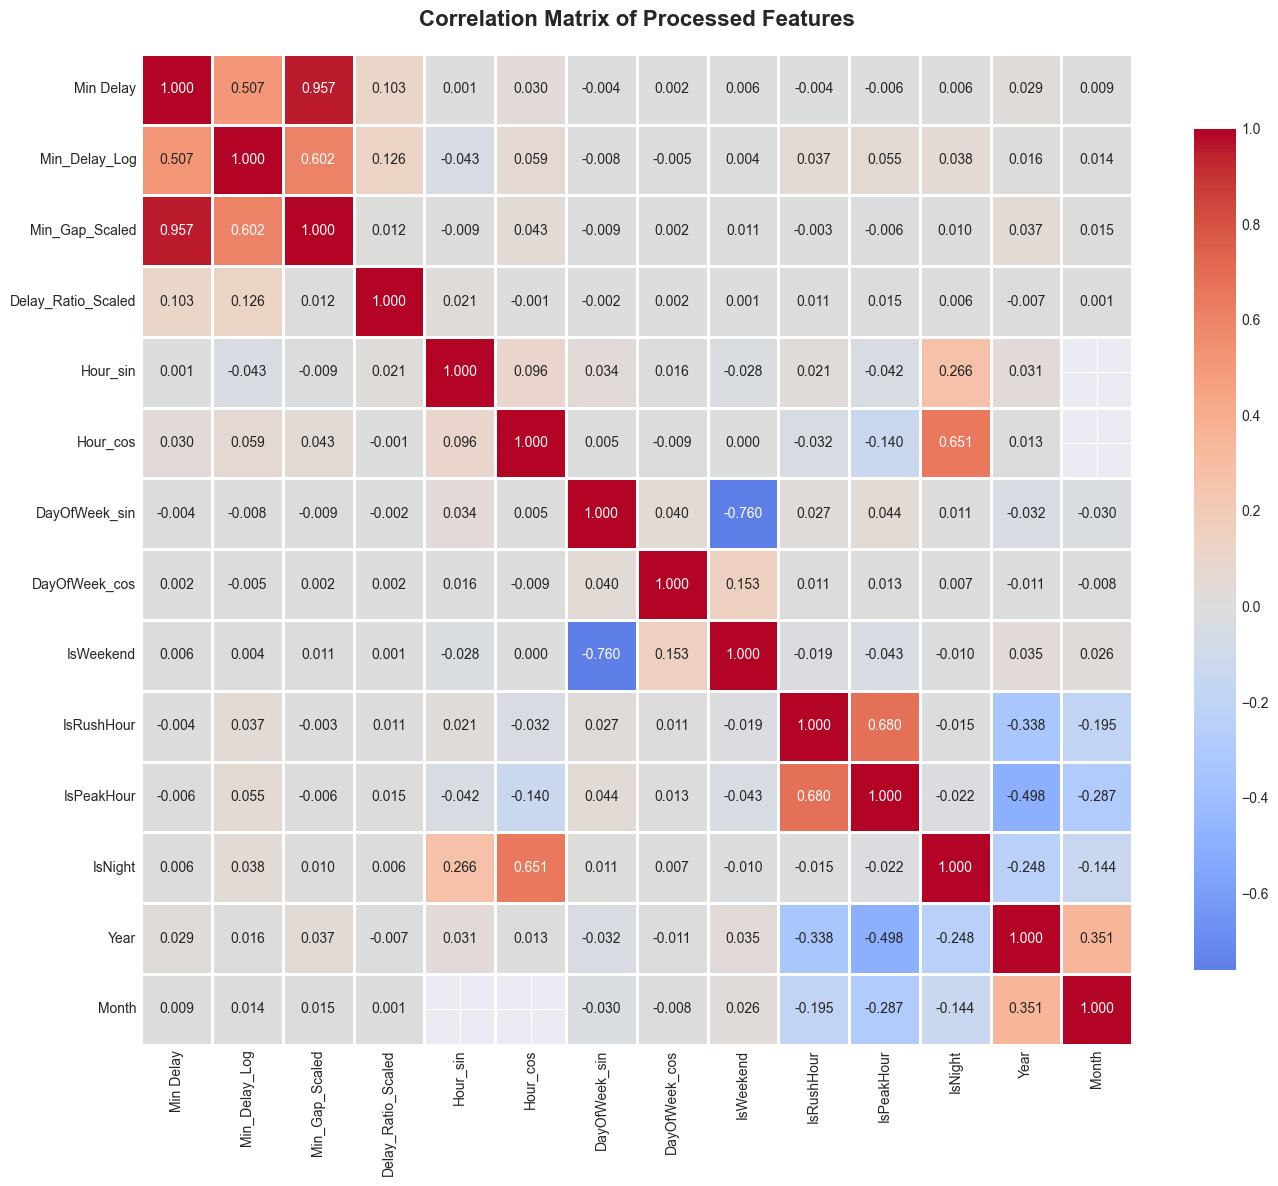


Correlations with Min Delay (target):
Min Delay             1.000000
Min_Gap_Scaled        0.956695
Min_Delay_Log         0.507140
Delay_Ratio_Scaled    0.103233
Hour_cos              0.030480
Year                  0.029314
Month                 0.008796
IsNight               0.006359
IsWeekend             0.005661
DayOfWeek_cos         0.001580
Hour_sin              0.001217
IsRushHour           -0.003512
DayOfWeek_sin        -0.004087
IsPeakHour           -0.006370
Name: Min Delay, dtype: float64


In [121]:
# Correlation analysis of processed features
print("=" * 70)
print("CORRELATION ANALYSIS - PROCESSED FEATURES")
print("=" * 70)

# Select numerical features for correlation
corr_features = ['Min Delay', 'Min_Delay_Log', 'Min_Gap_Scaled', 'Delay_Ratio_Scaled',
                'Hour_sin', 'Hour_cos', 'DayOfWeek_sin', 'DayOfWeek_cos',
                'IsWeekend', 'IsRushHour', 'IsPeakHour', 'IsNight', 'Year', 'Month']
corr_features = [f for f in corr_features if f in df.columns]

correlation_matrix = df[corr_features].corr()

# Visualize correlation matrix
plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Processed Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Correlations with target
print("\nCorrelations with Min Delay (target):")
delay_corr = correlation_matrix['Min Delay'].sort_values(ascending=False)
print(delay_corr)

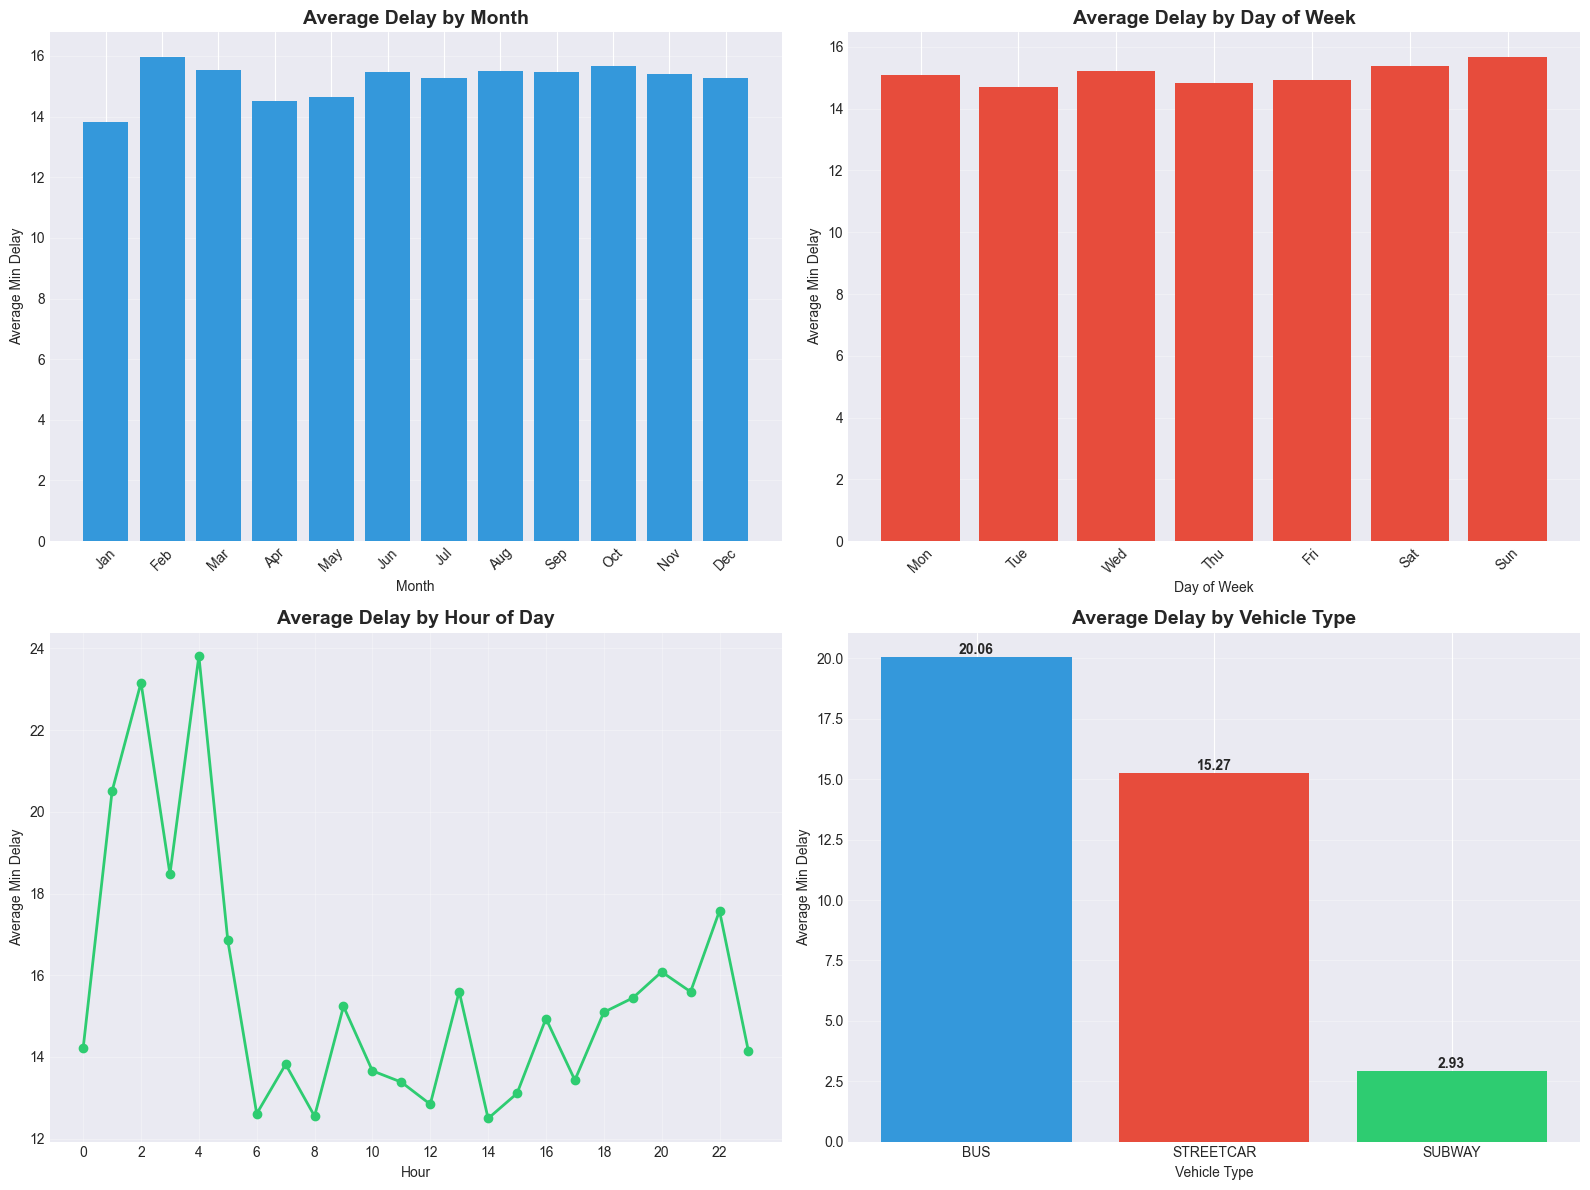

In [122]:
# Temporal patterns in processed data
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Average delay by month
monthly_avg = df.groupby('Month')['Min Delay'].mean()
axes[0, 0].bar(range(1, 13), monthly_avg.values, color='#3498db')
axes[0, 0].set_title('Average Delay by Month', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Average Min Delay')
axes[0, 0].set_xticks(range(1, 13))
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
axes[0, 0].set_xticklabels(month_names, rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Average delay by day of week
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_avg = df.groupby('DayName')['Min Delay'].mean().reindex(dow_order)
axes[0, 1].bar(range(len(dow_order)), dow_avg.values, color='#e74c3c')
axes[0, 1].set_title('Average Delay by Day of Week', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Day of Week')
axes[0, 1].set_ylabel('Average Min Delay')
axes[0, 1].set_xticks(range(len(dow_order)))
axes[0, 1].set_xticklabels([d[:3] for d in dow_order], rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Average delay by hour
hourly_avg = df.groupby('Hour')['Min Delay'].mean()
axes[1, 0].plot(hourly_avg.index, hourly_avg.values, marker='o', linewidth=2, markersize=6, color='#2ecc71')
axes[1, 0].set_title('Average Delay by Hour of Day', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Hour')
axes[1, 0].set_ylabel('Average Min Delay')
axes[1, 0].set_xticks(range(0, 24, 2))
axes[1, 0].grid(alpha=0.3)

# 4. Delay by vehicle type
delay_by_type = df.groupby('Vehicle_Type')['Min Delay'].mean()
axes[1, 1].bar(delay_by_type.index, delay_by_type.values, color=['#3498db', '#e74c3c', '#2ecc71'])
axes[1, 1].set_title('Average Delay by Vehicle Type', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Vehicle Type')
axes[1, 1].set_ylabel('Average Min Delay')
axes[1, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(delay_by_type.values):
    axes[1, 1].text(i, v, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [123]:
# Assess normalization needs
print("=" * 70)
print("NORMALIZATION NEEDS ASSESSMENT")
print("=" * 70)

numerical_features = ['Min Delay', 'Min Gap', 'Vehicle', 'Hour']
normalization_assessment = pd.DataFrame()

for col in numerical_features:
    if col in df.columns:
        data = df[col].dropna()
        mean_val = data.mean()
        std_val = data.std()
        min_val = data.min()
        max_val = data.max()
        range_val = max_val - min_val
        cv = std_val / mean_val if mean_val != 0 else np.inf  # Coefficient of variation
        
        normalization_assessment = pd.concat([normalization_assessment, pd.DataFrame({
            'Feature': [col],
            'Mean': [mean_val],
            'Std': [std_val],
            'Min': [min_val],
            'Max': [max_val],
            'Range': [range_val],
            'CV': [cv],
            'Needs_Normalization': [abs(cv) > 1 or range_val > 100]
        })], ignore_index=True)

print("\nNormalization Assessment:")
print(normalization_assessment.to_string(index=False))

NORMALIZATION NEEDS ASSESSMENT

Normalization Assessment:
  Feature        Mean         Std   Min     Max   Range       CV  Needs_Normalization
Min Delay   15.085444   42.164710 -30.0  1158.0  1188.0 2.795059                 True
  Min Gap   23.892572   44.790072   0.0  1158.0  1158.0 1.874644                 True
  Vehicle 4947.806705 3564.310998   0.0 98035.0 98035.0 0.720382                 True
     Hour   11.588297    5.547492   0.0    23.0    23.0 0.478715                False


## Appendix A — Correlation Analysis (optional)

CORRELATION ANALYSIS

Correlation Matrix:
           Min Delay  Min Gap   Year  Month  DayOfWeek   Hour  Vehicle
Min Delay      1.000    0.957  0.029  0.009      0.004 -0.006    0.037
Min Gap        0.957    1.000  0.037  0.015      0.009  0.004    0.074
Year           0.029    0.037  1.000  0.351      0.036 -0.021    0.035
Month          0.009    0.015  0.351  1.000      0.027    NaN    0.024
DayOfWeek      0.004    0.009  0.036  0.027      1.000  0.026   -0.004
Hour          -0.006    0.004 -0.021    NaN      0.026  1.000   -0.031
Vehicle        0.037    0.074  0.035  0.024     -0.004 -0.031    1.000


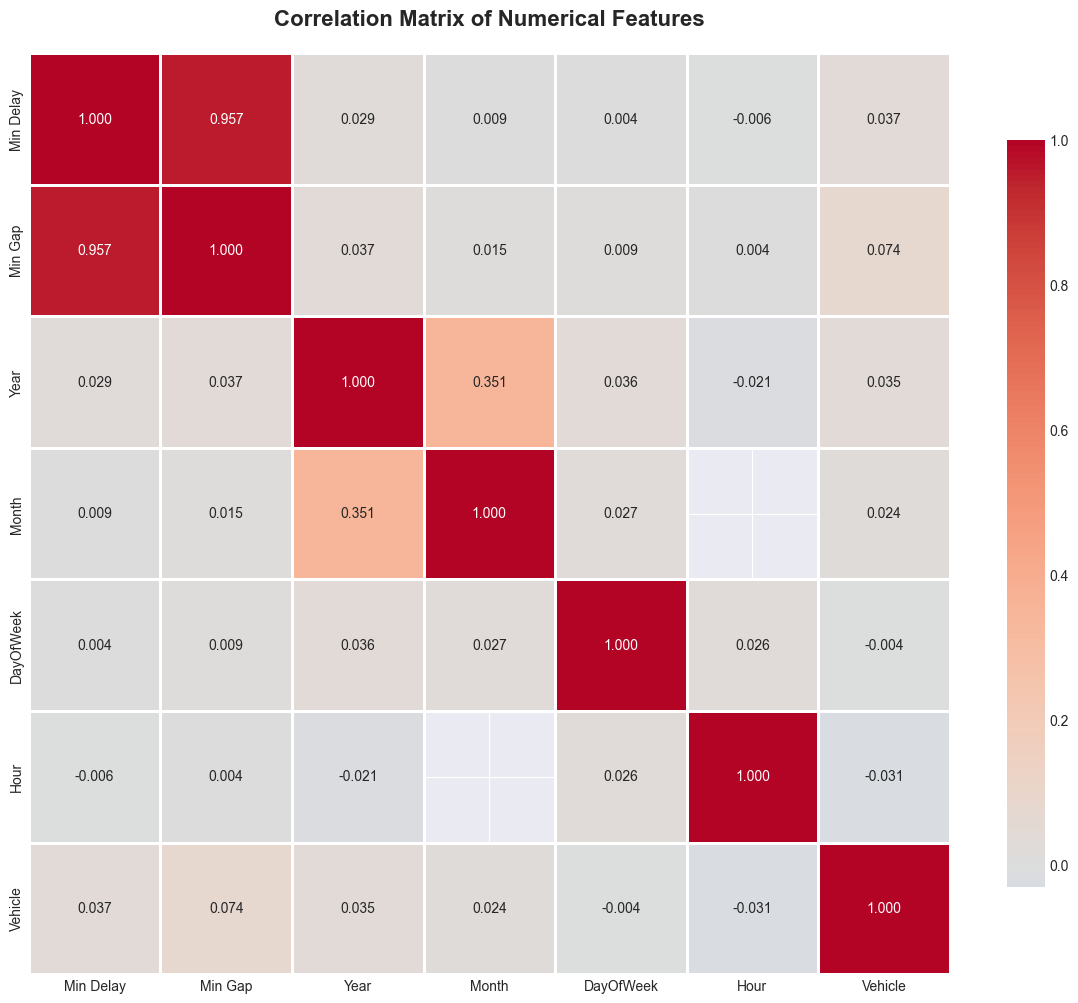


Correlations with Min Delay (target variable):
Min Delay    1.000000
Min Gap      0.956695
Vehicle      0.036637
Year         0.029314
Month        0.008796
DayOfWeek    0.004238
Hour        -0.006276
Name: Min Delay, dtype: float64


In [124]:
# Correlation analysis
print("=" * 70)
print("CORRELATION ANALYSIS")
print("=" * 70)

# Select numerical columns for correlation
corr_cols = ['Min Delay', 'Min Gap', 'Year', 'Month', 'DayOfWeek', 'Hour', 'Vehicle']
corr_cols = [col for col in corr_cols if col in df.columns]

correlation_matrix = df[corr_cols].corr()

print("\nCorrelation Matrix:")
print(correlation_matrix.round(3))

# Visualize correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Numerical Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Strong correlations with target (Min Delay)
print("\nCorrelations with Min Delay (target variable):")
delay_corr = correlation_matrix['Min Delay'].sort_values(ascending=False)
print(delay_corr)

## 13) Training Pipeline (LightGBM + XGBoost)

This section adds a production-oriented training pipeline using temporal validation.

Notebook assumptions for this section:
- `SUBWAY`, `BUS`, and `STREETCAR` all remain in scope for analysis and modeling.
- The training flow is separated into one cell per stage for easier review and iteration.
- `Month` is included as an explicit model input because seasonality matters for the SaaS use case.
- The outputs are prepared with SaaS reuse in mind, including heatmap-ready aggregated predictions.

Pipeline stages:
1. Dependency check and setup
2. Build the modeling base dataframe
3. Clean target and derive time features
4. Temporal split and train-only outlier cap
5. Feature definition and preprocessing
6. Train LightGBM
7. Train XGBoost
8. Compare models
9. Save artifacts and heatmap-ready outputs

In [125]:
# Stage 1: training dependencies and setup
from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder

warnings.filterwarnings("ignore")

from lightgbm import LGBMRegressor

from xgboost import XGBRegressor



In [126]:
# Stage 2: build the modeling base dataframe
if 'df' in globals() and isinstance(df, pd.DataFrame):
    model_df = df.copy()
else:
    BASE_DIR = Path.cwd().resolve().parent
    processed_path = BASE_DIR / 'aiProject' / 'outputs' / 'ttc_delays_2017_2025_unified_with_coords_corrected_treated.csv'
    if not processed_path.exists():
        raise FileNotFoundError(
            f"Could not find processed dataset at: {processed_path}. Run the notebook from the top first."
        )
    model_df = pd.read_csv(processed_path)

print(f"Model base shape: {model_df.shape}")
print(model_df['Vehicle_Type'].value_counts(dropna=False))

Model base shape: (439717, 42)
Vehicle_Type
BUS          263762
SUBWAY       108912
STREETCAR     67043
Name: count, dtype: int64


In [127]:
# Stage 3: clean target and derive time features
if 'Date' not in model_df.columns or 'Time' not in model_df.columns:
    raise ValueError("Expected columns `Date` and `Time` were not found.")

raw_target = pd.to_numeric(model_df['Min Delay'], errors='coerce')
negative_target_rows = int((raw_target < 0).sum())

model_df['EventDateTime'] = pd.to_datetime(
    model_df['Date'].astype(str) + ' ' + model_df['Time'].astype(str),
    errors='coerce'
)
model_df['Min Delay'] = raw_target
model_df = model_df.dropna(subset=['EventDateTime', 'Min Delay']).copy()
model_df['Min Delay'] = model_df['Min Delay'].clip(lower=0)

model_df['Year'] = model_df['EventDateTime'].dt.year
model_df['Month'] = model_df['EventDateTime'].dt.month
model_df['DayOfWeek'] = model_df['EventDateTime'].dt.dayofweek
model_df['Hour'] = model_df['EventDateTime'].dt.hour

if 'Min Gap' in model_df.columns:
    min_gap_num = pd.to_numeric(model_df['Min Gap'], errors='coerce')
    model_df['Min Gap'] = min_gap_num
    model_df['Delay_Ratio'] = model_df['Min Delay'] / (min_gap_num.fillna(0) + 1)
else:
    model_df['Min Gap'] = np.nan
    model_df['Delay_Ratio'] = np.nan

print(f"Rows with negative delay clipped to zero: {negative_target_rows:,}")
print(f"Model dataframe after cleaning: {model_df.shape}")
print(model_df['Min Delay'].describe())

Rows with negative delay clipped to zero: 2
Model dataframe after cleaning: (411034, 43)
count    411034.000000
mean         15.132943
std          42.411364
min           0.000000
25%           3.000000
50%          10.000000
75%          15.000000
max         999.000000
Name: Min Delay, dtype: float64


In [128]:
# Stage 4: temporal split and train-only outlier cap
train_df = model_df[model_df['Year'] <= 2023].copy()
val_df = model_df[model_df['Year'] == 2024].copy()
test_df = model_df[model_df['Year'] == 2025].copy()

if len(train_df) == 0 or len(val_df) == 0 or len(test_df) == 0:
    model_df = model_df.sort_values('EventDateTime').reset_index(drop=True)
    n = len(model_df)
    train_end = int(n * 0.70)
    val_end = int(n * 0.85)
    train_df = model_df.iloc[:train_end].copy()
    val_df = model_df.iloc[train_end:val_end].copy()
    test_df = model_df.iloc[val_end:].copy()
    print("Fallback chronological split used (70/15/15).")

upper_cap = float(train_df['Min Delay'].quantile(0.995))
train_df['Min Delay'] = train_df['Min Delay'].clip(upper=upper_cap)
val_df['Min Delay'] = val_df['Min Delay'].clip(upper=upper_cap)
test_df['Min Delay'] = test_df['Min Delay'].clip(upper=upper_cap)

print(f"Train shape: {train_df.shape}")
print(f"Validation shape: {val_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"Target upper cap from train only: {upper_cap:.2f}")

Train shape: (207561, 43)
Validation shape: (100312, 43)
Test shape: (103161, 43)
Target upper cap from train only: 265.00


In [129]:
# Stage 5: feature definition and preprocessing
# Keep only features that are realistic at SaaS inference time.
# We intentionally exclude leakage-prone or unavailable inputs such as
# `Delay_Ratio`, `Min Gap`, `Vehicle`, `Code`, and `Station`.
# `Month` is kept because seasonality is relevant and will be provided by the frontend.
candidate_features = [
    'Vehicle_Type',
    'Month', 'Hour', 'DayOfWeek',
    'IsWeekend', 'IsRushHour', 'IsPeakHour', 'IsNight',
    'Latitude', 'Longitude'
]
features = [c for c in candidate_features if c in model_df.columns]

categorical_features = [c for c in ['Vehicle_Type'] if c in features]
numeric_features = [c for c in features if c not in categorical_features]

X_train = train_df[features].copy()
y_train = train_df['Min Delay'].copy()
X_val = val_df[features].copy()
y_val = val_df['Min Delay'].copy()
X_test = test_df[features].copy()
y_test = test_df['Min Delay'].copy()

preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
            ]),
            categorical_features
        ),
        (
            'num',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median'))
            ]),
            numeric_features
        )
    ],
    remainder='drop'
)

X_train_t = preprocessor.fit_transform(X_train)
X_val_t = preprocessor.transform(X_val)
X_test_t = preprocessor.transform(X_test)

feature_summary = pd.DataFrame({
    'feature': features,
    'feature_type': ['categorical' if f in categorical_features else 'numeric' for f in features]
})

print(f"Total inference-safe features used: {len(features)}")
display(feature_summary)

Total inference-safe features used: 10


,feature,feature_type
0,Vehicle_Type,categorical
1,Month,numeric
2,Hour,numeric
3,DayOfWeek,numeric
4,IsWeekend,numeric
5,IsRushHour,numeric
6,IsPeakHour,numeric
7,IsNight,numeric
8,Latitude,numeric
9,Longitude,numeric


In [130]:
# Stage 6: train LightGBM
lgbm = LGBMRegressor(
    n_estimators=700,
    learning_rate=0.03,
    num_leaves=63,
    subsample=0.85,
    colsample_bytree=0.85,
    random_state=42,
    objective='regression',
    n_jobs=-1
)

lgbm.fit(X_train_t, y_train)
lgbm_val_pred = lgbm.predict(X_val_t)
lgbm_test_pred = lgbm.predict(X_test_t)

print("LightGBM trained successfully.")
print(f"Validation prediction sample size: {len(lgbm_val_pred):,}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001821 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 558
[LightGBM] [Info] Number of data points in the train set: 207561, number of used features: 7
[LightGBM] [Info] Start training from score 13.564369
LightGBM trained successfully.
Validation prediction sample size: 100,312


In [131]:
# Stage 7: train XGBoost
xgb = XGBRegressor(
    n_estimators=700,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_lambda=1.0,
    random_state=42,
    objective='reg:squarederror',
    n_jobs=-1
)

xgb.fit(X_train_t, y_train)
xgb_val_pred = xgb.predict(X_val_t)
xgb_test_pred = xgb.predict(X_test_t)

print("XGBoost trained successfully.")
print(f"Validation prediction sample size: {len(xgb_val_pred):,}")

XGBoost trained successfully.
Validation prediction sample size: 100,312


In [132]:
# Stage 8: compare models on validation and test

def regression_metrics(y_true, y_pred):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    medae = float(median_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))
    p90 = float(np.percentile(np.abs(y_true - y_pred), 90))
    return {
        'rmse': rmse,
        'mae': mae,
        'medae': medae,
        'r2': r2,
        'abs_error_p90': p90
    }

metrics = {
    'lightgbm': {
        'val': regression_metrics(y_val, lgbm_val_pred),
        'test': regression_metrics(y_test, lgbm_test_pred),
    },
    'xgboost': {
        'val': regression_metrics(y_val, xgb_val_pred),
        'test': regression_metrics(y_test, xgb_test_pred),
    }
}

results_df = pd.DataFrame([
    {'model': 'lightgbm', 'split': 'val', **metrics['lightgbm']['val']},
    {'model': 'lightgbm', 'split': 'test', **metrics['lightgbm']['test']},
    {'model': 'xgboost', 'split': 'val', **metrics['xgboost']['val']},
    {'model': 'xgboost', 'split': 'test', **metrics['xgboost']['test']},
])

best_model_name = min(metrics.keys(), key=lambda m: metrics[m]['val']['rmse'])
best_model = lgbm if best_model_name == 'lightgbm' else xgb
best_test_pred = lgbm_test_pred if best_model_name == 'lightgbm' else xgb_test_pred

print(json.dumps(metrics, indent=2))
print(f"\nBest model by validation RMSE: {best_model_name}")
display(results_df)

{
  "lightgbm": {
    "val": {
      "rmse": 28.06753684973478,
      "mae": 11.215126544614815,
      "medae": 5.179914088381423,
      "r2": 0.06349568001714823,
      "abs_error_p90": 19.065852467506165
    },
    "test": {
      "rmse": 27.566076558010213,
      "mae": 11.480132789540251,
      "medae": 5.462505863805871,
      "r2": 0.06693590020858575,
      "abs_error_p90": 19.872332611180077
    }
  },
  "xgboost": {
    "val": {
      "rmse": 28.158564404486416,
      "mae": 11.320971800123147,
      "medae": 5.24523138999939,
      "r2": 0.05741136027468163,
      "abs_error_p90": 19.572270011901857
    },
    "test": {
      "rmse": 27.64523856832562,
      "mae": 11.592190850454832,
      "medae": 5.575475692749023,
      "r2": 0.06156921068811294,
      "abs_error_p90": 20.35782241821289
    }
  }
}

Best model by validation RMSE: lightgbm


,model,split,rmse,mae,medae,r2,abs_error_p90
0,lightgbm,val,28.067537,11.215127,5.179914,0.063496,19.065852
1,lightgbm,test,27.566077,11.480133,5.462506,0.066936,19.872333
2,xgboost,val,28.158564,11.320972,5.245231,0.057411,19.572270
3,xgboost,test,27.645239,11.592191,5.575476,0.061569,20.357822


In [133]:
# Stage 9: retrain best model on train+validation and save production bundle
BASE_DIR = Path.cwd().resolve().parent
ARTIFACTS_DIR = BASE_DIR / 'aiProject' / 'outputs' / 'model_artifacts'
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

trainval_df = pd.concat([train_df, val_df], axis=0, ignore_index=True)
X_trainval = trainval_df[features].copy()
y_trainval = trainval_df['Min Delay'].copy()
X_test_final = test_df[features].copy()
y_test_final = test_df['Min Delay'].copy()

final_preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
            ]),
            categorical_features
        ),
        (
            'num',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median'))
            ]),
            numeric_features
        )
    ],
    remainder='drop'
)

X_trainval_t = final_preprocessor.fit_transform(X_trainval)
X_test_final_t = final_preprocessor.transform(X_test_final)

final_model = best_model.__class__(**best_model.get_params())
final_model.fit(X_trainval_t, y_trainval)
final_test_pred = final_model.predict(X_test_final_t)
final_test_metrics = regression_metrics(y_test_final, final_test_pred)

production_bundle = {
    'model': final_model,
    'preprocessor': final_preprocessor,
    'features': features,
    'categorical_features': categorical_features,
    'numeric_features': numeric_features,
    'target_name': 'Min Delay',
    'vehicle_scope': ['BUS', 'STREETCAR', 'SUBWAY'],
    'best_model_name': best_model_name,
    'validation_metrics': metrics[best_model_name]['val'],
    'test_metrics_before_refit': metrics[best_model_name]['test'],
    'test_metrics_after_refit': final_test_metrics,
}

joblib.dump(preprocessor, ARTIFACTS_DIR / 'preprocessor_all_modes.joblib')
joblib.dump(lgbm, ARTIFACTS_DIR / 'lgbm_all_modes.joblib')
joblib.dump(xgb, ARTIFACTS_DIR / 'xgb_all_modes.joblib')
joblib.dump(best_model, ARTIFACTS_DIR / 'best_model_all_modes.joblib')
joblib.dump(production_bundle, ARTIFACTS_DIR / 'model.pkl')

export_metrics = {
    **metrics,
    'production_bundle': {
        'best_model_name': best_model_name,
        'test_metrics_after_refit': final_test_metrics,
        'features': features,
    }
}

with open(ARTIFACTS_DIR / 'metrics_all_modes.json', 'w', encoding='utf-8') as f:
    json.dump(export_metrics, f, indent=2)

heatmap_df = test_df[['EventDateTime', 'Latitude', 'Longitude', 'Vehicle_Type', 'Month']].copy()
heatmap_df['pred_delay_min'] = final_test_pred
heatmap_df['Hour'] = heatmap_df['EventDateTime'].dt.hour
heatmap_df['DayOfWeek'] = heatmap_df['EventDateTime'].dt.dayofweek
heatmap_df['Latitude_Bin'] = heatmap_df['Latitude'].round(3)
heatmap_df['Longitude_Bin'] = heatmap_df['Longitude'].round(3)

heatmap_agg = (
    heatmap_df
    .dropna(subset=['Latitude', 'Longitude'])
    .groupby(['Vehicle_Type', 'Month', 'DayOfWeek', 'Hour', 'Latitude_Bin', 'Longitude_Bin'], as_index=False)
    .agg(
        pred_delay_mean=('pred_delay_min', 'mean'),
        pred_delay_p90=('pred_delay_min', lambda x: np.percentile(x, 90)),
        n_events=('pred_delay_min', 'size')
    )
)

heatmap_agg.to_csv(ARTIFACTS_DIR / 'heatmap_predictions_test_agg.csv', index=False)

print(f"Final production model fit completed with {best_model_name} on train+validation.")
print(f"Test metrics after refit: {final_test_metrics}")
print(f"Artifacts saved to: {ARTIFACTS_DIR}")
for p in sorted(ARTIFACTS_DIR.glob('*')):
    print(f" - {p.name}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001728 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 557
[LightGBM] [Info] Number of data points in the train set: 307873, number of used features: 7
[LightGBM] [Info] Start training from score 13.793873
Final production model fit completed with lightgbm on train+validation.
Test metrics after refit: {'rmse': 27.49956298589274, 'mae': 11.407988158675202, 'medae': 5.467356036561194, 'r2': 0.07143320709552603, 'abs_error_p90': 19.47088479729574}
Artifacts saved to: /Users/feliperosa/Downloads/02_codigos/github/centennialCollege_AICapstoneProject/aiProject/outputs/model_artifacts
 - best_model_all_modes.joblib
 - best_model_bus_streetcar.joblib
 - heatmap_predictions_test_agg.csv
 - lgbm_all_modes.joblib
 - lgbm_bus_streetcar.joblib
 - metrics_all_modes.json
 - metrics_bus_streetcar.json
 -